## EEG


In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
%matplotlib inline

In [101]:
eeg_data = pd.read_csv('./EEG/eeg-data.csv', low_memory=False)
eeg_data.rename(columns={'Unnamed: 0': 'index'}, inplace=True)
def extract_eeg_lists(eeg_power_str): # Runs faster thatn ast.literal_eval() and eval()
    return [float(n) for n in eeg_power_str.split("[")[1].split("]")[0].split(",")]
eeg_data.eeg_power = eeg_data.eeg_power.apply(extract_eeg_lists)
eeg_data.raw_values = eeg_data.raw_values.apply(extract_eeg_lists)
original_size = eeg_data.shape[0]
print(f"Original size of the dataset: {original_size}")

Original size of the dataset: 30013


In [23]:
eeg_data.columns

Index(['index', 'id', 'indra_time', 'browser_latency', 'reading_time',
       'attention_esense', 'meditation_esense', 'eeg_power', 'raw_values',
       'signal_quality', 'createdAt', 'updatedAt', 'label'],
      dtype='object')

In [15]:
random_index = np.random.randint(0, len(eeg_data))
print(f"size of each eeg power: {len(eeg_data.eeg_power[random_index])}")
print(f"size of each raw value: {len(eeg_data.raw_values[random_index])}")

size of each eeg power: 8
size of each raw value: 512


In [44]:
print(f"Number of IDs: {len(list(eeg_data.id.value_counts().keys()))}")
print(f"Number of records: {len(list(eeg_data.index.value_counts().keys()))}")
print(f"Number of attention essences: {len(list(eeg_data.attention_esense.value_counts().keys()))}")
print(f"Number of meditation essences: {len(list(eeg_data.meditation_esense.value_counts().keys()))}")
print(f"Number of labels: {len(list(eeg_data.label.value_counts().keys()))}")

Number of IDs: 30
Number of records: 30013
Number of attention essences: 61
Number of meditation essences: 61
Number of labels: 68


### The number of "unlabeled" labels is quite large (>20k), which means we lose two-third of the data! :(

# Labels distribution


In [102]:
eeg_data = eeg_data[eeg_data.label != 'unlabeled']
print(f"Size of the dataset after removing unlabeled data: {eeg_data.shape[0]}")
print(f"Data loss percentage: {(1 - eeg_data.shape[0] / original_size) * 100:.2f}%")

Size of the dataset after removing unlabeled data: 9959
Data loss percentage: 66.82%


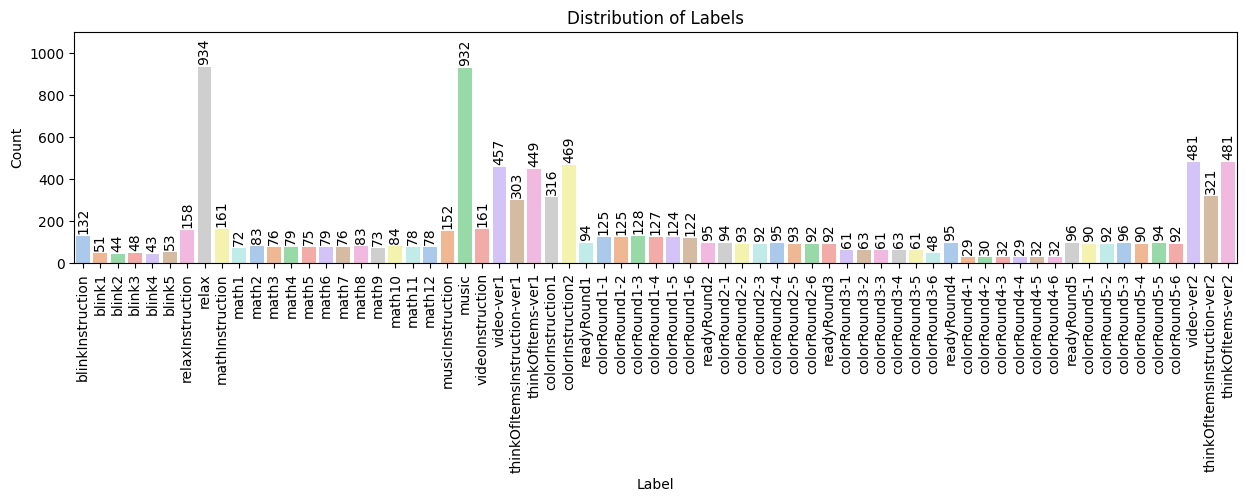

In [105]:
plt.figure(figsize=(15, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count + 10, str(count), ha='center', va='bottom', rotation=90)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.ylim(0, 1100)
plt.show()

# Sample power and raw values


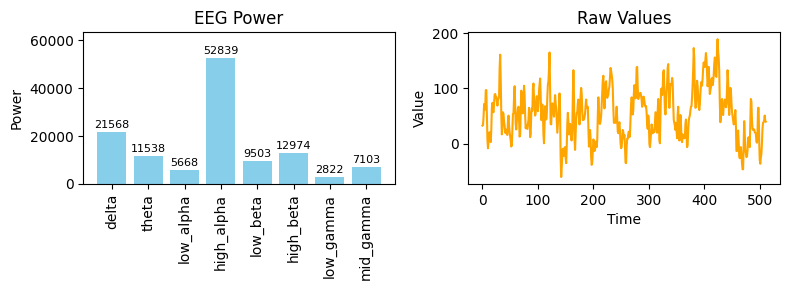

In [104]:
POWER_BANDS = ['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma']
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].bar(POWER_BANDS, eeg_data.eeg_power[random_index], color='skyblue')
for p in axs[0].patches:
    axs[0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                    textcoords='offset points')
axs[0].set_title('EEG Power')
axs[0].set_ylabel('Power')
axs[0].set_ylim(0, max(eeg_data.eeg_power[random_index]) * 1.2)
axs[0].set_xticks(range(len(POWER_BANDS)))
axs[0].set_xticklabels(POWER_BANDS, rotation=90)

axs[1].plot(eeg_data.raw_values[random_index], label='Raw Values', color='orange')
axs[1].set_title('Raw Values')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Value')

plt.tight_layout()
plt.show()


# Raw values stats


In [72]:
def summarize_vector(values, prefix):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {
            f"{prefix}_len": 0.0,
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_q05": np.nan,
            f"{prefix}_q95": np.nan,
            f"{prefix}_abs_mean": np.nan,
            f"{prefix}_clip_ratio": np.nan,
        }

    return {
        f"{prefix}_len": float(arr.size),
        f"{prefix}_mean": float(arr.mean()),
        f"{prefix}_std": float(arr.std()),
        f"{prefix}_min": float(arr.min()),
        f"{prefix}_max": float(arr.max()),
        f"{prefix}_median": float(np.median(arr)),
        f"{prefix}_q05": float(np.quantile(arr, 0.05)),
        f"{prefix}_q95": float(np.quantile(arr, 0.95)),
        f"{prefix}_abs_mean": float(np.mean(np.abs(arr))),
        f"{prefix}_clip_ratio": float(np.mean(np.abs(arr) >= 2047.0)),
    }

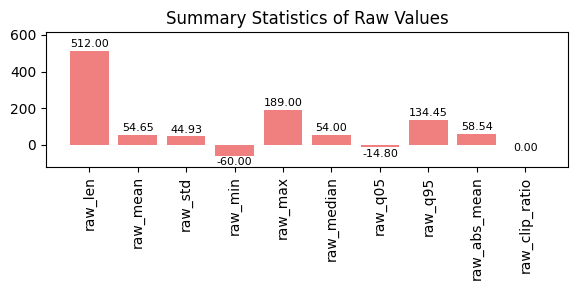

In [103]:
raw_features = summarize_vector(eeg_data.raw_values[random_index], 'raw')
plt.figure(figsize=(6, 3))
plt.bar(raw_features.keys(), raw_features.values(), color='lightcoral')
for i, value in enumerate(raw_features.values()):
    plt.text(i, value + math.copysign(10, value),
            f'{value:.2f}', ha='center', va='bottom' if value > 0 else 'top', fontsize=8)
plt.title('Summary Statistics of Raw Values')
plt.xticks(rotation=90)
plt.ylim(min(raw_features.values()) * 2, max(raw_features.values()) * 1.2)
plt.tight_layout()
plt.show()

### To further preprocess the data, all these raw value stats could be considered as additional features (new columns).

### Then, train/val/test split for some initial model development and evaluation.

### Class (label) balance is very important, also subject leakage!

### More advanced models (CNN, RNN, Transformer) could be also developed without these features.
